In [28]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px


In [29]:
ano = 2022


In [30]:
data_dir = Path("data")
INDIR = Path(f"../data/data_model/{ano}")
OUTDIR_IMG = Path(f"../report/img/{ano}")
OUTDIR_IMG.mkdir(parents=True, exist_ok=True)

In [31]:
arquivo = INDIR / f"ANALISE_NOTAS_ENEM_MUNICIPIOS_BRASIL_CLUSTERS_{ano}.csv"
df = pd.read_csv(arquivo, sep=",")

In [32]:
df.head()

,MUNICIPIO,UF,QTD_PARTICIPANTES,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA,MEDIA_GERAL,RENDA_FAMILIAR_SM_MEDIA,CLUSTER
0,ABAETETUBA,PA,3313,471.502113,499.651343,482.121038,491.876124,638.357984,516.701720,0.937169,0
1,ABAETÉ,MG,442,498.759955,536.630090,527.132353,567.233937,663.619910,558.675249,2.015306,2
2,ABREU E LIMA,PE,1256,484.963774,515.079299,510.794108,516.690924,620.732484,529.652118,1.088799,1
3,ACARAPE,CE,299,466.453512,487.839130,481.017391,491.493645,622.006689,509.762074,0.753133,0
4,ACARAÚ,CE,911,471.106257,495.193633,484.350494,522.769374,685.861690,531.856290,0.806239,1


In [33]:
df_dict_municipio = {
    0: df[df['CLUSTER'] == 0].copy().reset_index(drop=True),
    1: df[df['CLUSTER'] == 1].copy().reset_index(drop=True),
    2: df[df['CLUSTER'] == 2].copy().reset_index(drop=True)
}

Imagem salva em: ../report/img/2022/2022_DISTRIBUICAO_DAS_MEDIAS_DE_NOTAS_POR_CLUSTER.png


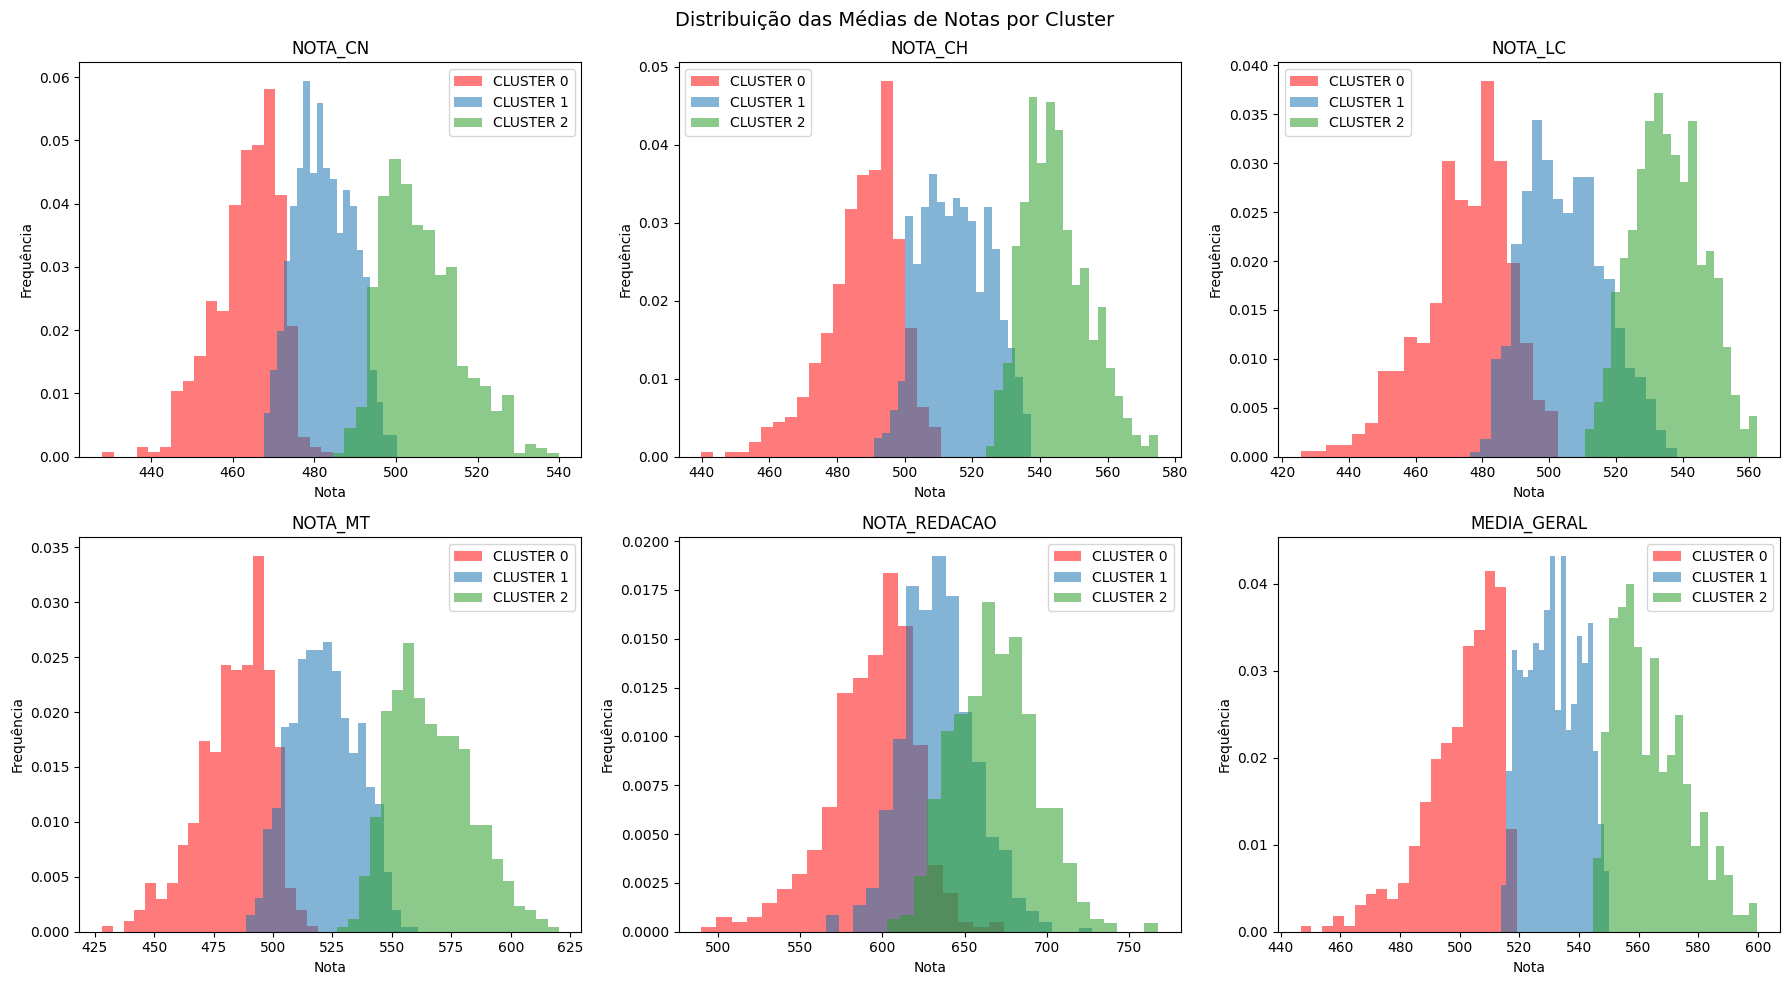

In [34]:
colunas_notas = [c for c in df.columns if c.startswith("NOTA_") and c.endswith("_MEDIA")]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cores_cluster = {0: "#ff0e0e", 1: "#1f77b4", 2: "#2ca02c"}
coluna_extra = next((c for c in ["MEDIA_GERAL", "MED9A_GERAL"] if c in df.columns), None)
if coluna_extra and coluna_extra not in colunas_notas:
    colunas_notas.append(coluna_extra)
for i, coluna in enumerate(colunas_notas):
    ax = axes[i]
    for cluster in sorted(df["CLUSTER"].unique()):
        ax.hist(
            df.loc[df["CLUSTER"] == cluster, coluna],
            bins=20,
            alpha=0.55,
            label=f"CLUSTER {cluster}",
            color=cores_cluster.get(cluster, None),
            density=True
        )
    ax.set_title(coluna.replace("NU_NOTA_", "").replace("_MEDIA", ""))
    ax.set_xlabel("Nota")
    ax.set_ylabel("Frequência")
    ax.legend()

for j in range(len(colunas_notas), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribuição das Médias de Notas por Cluster", fontsize=14)
plt.tight_layout()
caminho = OUTDIR_IMG / f"{ano}_DISTRIBUICAO_DAS_MEDIAS_DE_NOTAS_POR_CLUSTER.png"
fig.savefig(caminho, dpi=300, bbox_inches="tight")
print(f"Imagem salva em: {caminho}")
plt.show()

In [35]:
df.head()

,MUNICIPIO,UF,QTD_PARTICIPANTES,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA,MEDIA_GERAL,RENDA_FAMILIAR_SM_MEDIA,CLUSTER
0,ABAETETUBA,PA,3313,471.502113,499.651343,482.121038,491.876124,638.357984,516.701720,0.937169,0
1,ABAETÉ,MG,442,498.759955,536.630090,527.132353,567.233937,663.619910,558.675249,2.015306,2
2,ABREU E LIMA,PE,1256,484.963774,515.079299,510.794108,516.690924,620.732484,529.652118,1.088799,1
3,ACARAPE,CE,299,466.453512,487.839130,481.017391,491.493645,622.006689,509.762074,0.753133,0
4,ACARAÚ,CE,911,471.106257,495.193633,484.350494,522.769374,685.861690,531.856290,0.806239,1


In [36]:
renda_col = "RENDA_FAMILIAR_SM_MEDIA"

titulos = []
for c in colunas_notas:
    base = c.replace("NU_NOTA_", "").replace("_MEDIA", "")
    d = df[[renda_col, c]].dropna()
    corr = d[renda_col].corr(d[c])
    titulos.append(f"{base} (r={corr:.3f})")

fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=titulos,
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

for i, coluna in enumerate(colunas_notas):
    row = i // 3 + 1
    col = i % 3 + 1

    for cluster in sorted(df["CLUSTER"].unique()):
        dados = df[df["CLUSTER"] == cluster]
        dados_validos = dados[[renda_col, coluna, "MUNICIPIO", "UF", "QTD_PARTICIPANTES"]].dropna()

        fig.add_trace(
            go.Scatter(
                x=dados_validos[renda_col],
                y=dados_validos[coluna],
                mode="markers",
                marker=dict(size=6, color=cores_cluster.get(cluster)),
                opacity=0.7,
                name=f"CLUSTER {cluster}",
                showlegend=(i == 0),
                customdata=dados_validos[["MUNICIPIO", "UF", "QTD_PARTICIPANTES"]],
                hovertemplate=(
                    "Município: %{customdata[0]} (%{customdata[1]})<br>"
                    "Renda: %{x:.2f}<br>"
                    "Nota: %{y:.2f}<br>"
                    "Participantes: %{customdata[2]}<br>"
                    f"Cluster: {cluster}"
                    "<extra></extra>"
                )
            ),
            row=row,
            col=col
        )

    fig.update_xaxes(title_text="Renda Familiar Média (SM)", row=row, col=col)
    fig.update_yaxes(title_text="Nota Média", row=row, col=col)

fig.update_layout(
    title=f"Relação entre Renda Familiar Média e Notas por Cluster (ENEM {ano})",
    height=800,
    width=1200,
    template="plotly_white"
)

caminho = OUTDIR_IMG / f"{ano}_RELACAO_ENTRE_RENDA_FAMILIAR_MEDIA_E_NOTAS_POR_CLUSTER.png"
fig.write_image(str(caminho), scale=2)
print(f"Imagem salva em: {caminho}")
fig.show()


Imagem salva em: ../report/img/2022/2022_RELACAO_ENTRE_RENDA_FAMILIAR_MEDIA_E_NOTAS_POR_CLUSTER.png


In [ ]:

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"


In [ ]:
df_map = df_dict_uf[0].copy()

fig = px.choropleth(
    df_map,
    geojson=url,
    locations='UF',
    featureidkey='properties.sigla',
    color='MEDIA_GERAL',
    color_continuous_scale='Reds_r',
    title=f'Estados com piores rendimentos (Cluster 0 - ENEM {ano})',
    custom_data=[
        'UF',
        'MEDIA_GERAL',
        'RENDA_FAMILIAR_SM_MEDIA',
        'QTD_PARTICIPANTES'
    ]
)

fig.update_geos(fitbounds="locations", visible=False)

fig.update_traces(
    hovertemplate=(
        "Estado: %{customdata[0]}<br>"
        "Média geral: %{customdata[1]:.2f}<br>"
        "Renda média: %{customdata[2]:.2f}<br>"
        "Participantes: %{customdata[3]}<br>"
        "<extra></extra>"
    )
)

caminho = OUTDIR_IMG / f"{ano}_ESTADOS_COM_PIORES_RENDIMENTOS_CLUSTER_0.png"
fig.write_image(str(caminho), scale=2)
print(f"Imagem salva em: {caminho}")
fig.show()

Imagem salva em: ../report/img/2024/2024_ESTADOS_COM_PIORES_RENDIMENTOS_CLUSTER_0.png


In [ ]:
df_map = df_dict_uf[2].copy()

fig = px.choropleth(
    df_map,
    geojson=url,
    locations='UF',
    featureidkey='properties.sigla',
    color='MEDIA_GERAL',
    color_continuous_scale='Greens',
    title=f'Estados com melhores rendimentos (Cluster 2 - ENEM {ano})',
    custom_data=[
        'UF',
        'MEDIA_GERAL',
        'RENDA_FAMILIAR_SM_MEDIA',
        'QTD_PARTICIPANTES'
    ]
)

fig.update_geos(fitbounds="locations", visible=False)

fig.update_traces(
    hovertemplate=(
        "Estado: %{customdata[0]}<br>"
        "Média geral: %{customdata[1]:.2f}<br>"
        "Renda média: %{customdata[2]:.2f}<br>"
        "Participantes: %{customdata[3]}<br>"
        "<extra></extra>"
    )
)

caminho = OUTDIR_IMG / f"{ano}_ESTADOS_COM_MELHORES_RENDIMENTOS_CLUSTER_2.png"
fig.write_image(str(caminho), scale=2)
print(f"Imagem salva em: {caminho}")
fig.show()

Imagem salva em: ../report/img/2024/2024_ESTADOS_COM_MELHORES_RENDIMENTOS_CLUSTER_2.png


In [ ]:
df_map = df_dict_uf[1].copy()

fig = px.choropleth(
    df_map,
    geojson=url,
    locations='UF',
    featureidkey='properties.sigla',
    color='MEDIA_GERAL',
    color_continuous_scale='Blues',
    title=f'Estados com rendimentos intermediários (Cluster 1 - ENEM {ano})',
    custom_data=[
        'UF',
        'MEDIA_GERAL',
        'RENDA_FAMILIAR_SM_MEDIA',
        'QTD_PARTICIPANTES'
    ]
)

fig.update_geos(fitbounds="locations", visible=False)

fig.update_traces(
    hovertemplate=(
        "Estado: %{customdata[0]}<br>"
        "Média geral: %{customdata[1]:.2f}<br>"
        "Renda média: %{customdata[2]:.2f}<br>"
        "Participantes: %{customdata[3]}<br>"
        "<extra></extra>"
    )
)

caminho = OUTDIR_IMG / f"{ano}_ESTADOS_COM_RENDIMENTOS_INTERMEDIARIOS_CLUSTER_1.png"
fig.write_image(str(caminho), scale=2)
print(f"Imagem salva em: {caminho}")
fig.show()

Imagem salva em: ../report/img/2024/2024_ESTADOS_COM_RENDIMENTOS_INTERMEDIARIOS_CLUSTER_1.png
